# Binary Logistic Regression for Sentiment Analysis
### Implemented following Jurafsky & Martin, *Speech and Language Processing* (3rd ed.), Chapter 4

**Reference:** https://web.stanford.edu/~jurafsky/slp3/4.pdf

This notebook implements binary logistic regression **from scratch** — sigmoid function,
cross-entropy loss, and stochastic gradient descent — exactly as described in §4.2–4.5.

The **6 features** from §4.3.1 are used:

| Feature | Definition |
|---------|------------|
| x₁ | count of positive-lexicon words in doc |
| x₂ | count of negative-lexicon words in doc |
| x₃ | 1 if any negation word present, else 0 |
| x₄ | count of 1st- and 2nd-person pronouns |
| x₅ | 1 if `!` present, else 0 |
| x₆ | ln(word + punctuation token count) |

**VADER** is used as the positive/negative sentiment lexicon to populate x₁ and x₂.
The logistic regression classifier itself is hand-rolled NumPy — no sklearn `LogisticRegression`.

## 0 · Install dependencies

In [1]:
%pip install -q vaderSentiment nltk scikit-learn matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1 · Load mock training data

In [2]:
import json
import numpy as np
import pandas as pd

with open("mock_comments_100.json") as f:
    mock_data = json.load(f)

df = pd.DataFrame([
    {"text": d["raw_text"], "label": d["stance"]}
    for d in mock_data
])

# Binary encode: positive = 1, negative = 0
df["label_int"] = (df["label"] == "positive").astype(int)

print(f"Dataset: {len(df)} rows")
print(df["label"].value_counts())
df.head()

Dataset: 100 rows
label
negative    50
positive    50
Name: count, dtype: int64


,text,label,label_int
0,This doesn't handle the edge case where a pack...,negative,0
1,I tested this locally and it works perfectly. ...,positive,1
2,I think we're solving the wrong problem. The w...,negative,0
3,The performance overhead is negligible accordi...,positive,1
4,This forces an unnecessary dependency on ctype...,negative,0


## 2 · Build the 6-feature extractor (§4.3.1)

VADER's internal `_LEXICON` dictionary maps every word to a valence score.
We use it directly to classify each token as a positive or negative lexicon word
(x₁ and x₂), rather than using VADER's compound scorer — keeping the
classification decision entirely in our logistic regression model.

In [3]:
import re
import math
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# ── VADER lexicon ─────────────────────────────────────────────────────────────
# _LEXICON is a dict of {word: valence_score}.
# Positive words have score > 0; negative words have score < 0.
_vader = SentimentIntensityAnalyzer()
VADER_LEXICON = _vader.lexicon          # {word: float}

# ── Linguistic resources ──────────────────────────────────────────────────────
NEGATION_WORDS = {
    "no", "not", "never", "nobody", "nothing", "nowhere", "neither",
    "nor", "cannot", "can't", "won't", "don't", "doesn't", "didn't",
    "isn't", "aren't", "wasn't", "weren't", "without", "hardly",
    "barely", "scarcely", "n't"
}

FIRST_SECOND_PRONOUNS = {
    "i", "me", "my", "mine", "myself",
    "we", "us", "our", "ours", "ourselves",
    "you", "your", "yours", "yourself", "yourselves"
}

# ── Tokeniser: words + punctuation tokens (for x₆ log-length) ────────────────
def tokenise(text):
    """Split into word/punctuation tokens, lower-cased."""
    return re.findall(r"[\w']+|[.,!?;:]", text.lower())


def extract_features(text):
    """
    Return the 6-element feature vector described in Jurafsky & Martin §4.3.1.

    x1 – count of positive lexicon words  (VADER valence > 0)
    x2 – count of negative lexicon words  (VADER valence < 0)
    x3 – 1 if any negation word present
    x4 – count of 1st / 2nd person pronouns
    x5 – 1 if '!' present
    x6 – ln(total word + punctuation token count)
    """
    tokens = tokenise(text)

    x1 = sum(1 for t in tokens if VADER_LEXICON.get(t, 0) > 0)
    x2 = sum(1 for t in tokens if VADER_LEXICON.get(t, 0) < 0)
    x3 = int(any(t in NEGATION_WORDS for t in tokens))
    x4 = sum(1 for t in tokens if t in FIRST_SECOND_PRONOUNS)
    x5 = int("!" in text)
    x6 = math.log(len(tokens)) if len(tokens) > 0 else 0.0

    return np.array([x1, x2, x3, x4, x5, x6], dtype=float)


# ── Demo on the book's example sentence ──────────────────────────────────────
demo = (
    "It's hokey. There are virtually no surprises, and the writing is second-rate. "
    "So why was it so enjoyable? For one thing, the cast is great. Another nice "
    "touch is the music. I was overcome with the urge to get off the couch and "
    "start dancing. It sucked me in, and it'll do the same to you."
)
fv = extract_features(demo)
feature_names = ["x1 pos-lex", "x2 neg-lex", "x3 negation",
                 "x4 pronouns", "x5 !",       "x6 ln(len)"]
print("Book example feature vector:")
for name, val in zip(feature_names, fv):
    print(f"  {name:15s}: {val:.4f}")
print("  (Book reports x1=3, x2=2, x3=1, x4=3, x5=0, x6=ln(66)=4.19)")

Book example feature vector:
  x1 pos-lex     : 4.0000
  x2 neg-lex     : 2.0000
  x3 negation    : 1.0000
  x4 pronouns    : 3.0000
  x5 !           : 0.0000
  x6 ln(len)     : 4.2047
  (Book reports x1=3, x2=2, x3=1, x4=3, x5=0, x6=ln(66)=4.19)


In [4]:
# ── Extract features for the full dataset ────────────────────────────────────
X_all = np.vstack(df["text"].apply(extract_features).values)   # shape (100, 6)
y_all = df["label_int"].values                                  # shape (100,)

print(f"Feature matrix shape : {X_all.shape}")
print(f"Label vector shape   : {y_all.shape}")

# Feature summary
feat_df = pd.DataFrame(X_all, columns=feature_names)
feat_df["label"] = df["label"].values
feat_df.groupby("label").mean().round(3)

Feature matrix shape : (100, 6)
Label vector shape   : (100,)


,x1 pos-lex,x2 neg-lex,x3 negation,x4 pronouns,x5 !,x6 ln(len)
label,,,,,,
negative,0.68,0.78,0.46,0.30,0.00,2.645
positive,1.68,0.08,0.02,0.34,0.02,2.559


## 3 · Standardise features (§4.3.2)

Jurafsky §4.3.2 recommends standardising input features to zero mean / unit
variance (z-score) so that features with different ranges are comparable and
gradient descent converges reliably.

In [5]:
# Compute mean and std on the full dataset (fit on train only after splitting)
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# Standardise: fit on train, apply to both (§4.3.2, Eq. 4.9)
mu    = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0) + 1e-8   # add epsilon to avoid div-by-zero

X_train = (X_train_raw - mu) / sigma
X_test  = (X_test_raw  - mu) / sigma

print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")
print(f"Feature means after standardisation (train): {X_train.mean(axis=0).round(4)}")

Train: 80  |  Test: 20
Feature means after standardisation (train): [-0. -0. -0. -0.  0.  0.]


## 4 · Binary logistic regression — from scratch

Implementing the three components described in Chapter 4:

1. **Sigmoid** (§4.2, Eq. 4.4): maps the dot product z = w·x + b into a probability
2. **Cross-entropy loss** (§4.5): measures how far ŷ is from the true label y
3. **Stochastic gradient descent** (§4.6): updates w and b to minimise the loss

In [6]:
# ── §4.2  Sigmoid function (Eq. 4.4) ─────────────────────────────────────────
def sigmoid(z):
    """σ(z) = 1 / (1 + exp(-z))"""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))


# ── §4.5  Cross-entropy loss (Eq. 4.17) ──────────────────────────────────────
def cross_entropy_loss(y_hat, y):
    """
    L(ŷ, y) = -[ y·log(ŷ) + (1-y)·log(1-ŷ) ]
    Averaged over the batch.
    """
    eps = 1e-12
    return -np.mean(
        y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps)
    )


# ── §4.6  Stochastic Gradient Descent training ────────────────────────────────
def train_logistic_regression(
    X, y,
    learning_rate=0.1,
    epochs=200,
    random_state=42
):
    """
    Train binary logistic regression via SGD.

    Gradient of cross-entropy loss w.r.t. w (Eq. 4.22):
        ∂L/∂w = (ŷ - y) · x
        ∂L/∂b = (ŷ - y)

    Weight update (Eq. 4.23):
        w ← w - η · ∂L/∂w
        b ← b - η · ∂L/∂b
    """
    rng = np.random.default_rng(random_state)
    n_samples, n_features = X.shape

    # Initialise weights to zero (common starting point for logistic regression)
    w = np.zeros(n_features)
    b = 0.0

    loss_history = []

    for epoch in range(epochs):
        # Shuffle training examples each epoch (stochastic GD)
        indices = rng.permutation(n_samples)

        for i in indices:
            xi    = X[i]          # feature vector for one example
            yi    = y[i]          # true label (0 or 1)

            # Forward pass: compute ŷ = σ(w·x + b)  [§4.2, Eq. 4.5]
            z     = np.dot(w, xi) + b
            y_hat = sigmoid(z)

            # Backward pass: gradient of cross-entropy loss  [§4.5, Eq. 4.22]
            error = y_hat - yi
            grad_w = error * xi
            grad_b = error

            # Weight update  [§4.6, Eq. 4.23]
            w -= learning_rate * grad_w
            b -= learning_rate * grad_b

        # Compute epoch loss over full training set for monitoring
        y_hat_all = sigmoid(X @ w + b)
        loss = cross_entropy_loss(y_hat_all, y)
        loss_history.append(loss)

        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1:>3d}/{epochs}  |  cross-entropy loss: {loss:.4f}")

    return w, b, loss_history


print("Training binary logistic regression (SGD)...")
w, b, loss_history = train_logistic_regression(
    X_train, y_train,
    learning_rate=0.1,
    epochs=200
)

print("\nLearned weights:")
for name, wi in zip(feature_names, w):
    print(f"  w({name:15s}) = {wi:+.4f}")
print(f"  bias b              = {b:+.4f}")

Training binary logistic regression (SGD)...
  Epoch  20/200  |  cross-entropy loss: 0.3741
  Epoch  40/200  |  cross-entropy loss: 0.3740
  Epoch  60/200  |  cross-entropy loss: 0.3741
  Epoch  80/200  |  cross-entropy loss: 0.3749
  Epoch 100/200  |  cross-entropy loss: 0.3739
  Epoch 120/200  |  cross-entropy loss: 0.3744
  Epoch 140/200  |  cross-entropy loss: 0.3753
  Epoch 160/200  |  cross-entropy loss: 0.3747
  Epoch 180/200  |  cross-entropy loss: 0.3744
  Epoch 200/200  |  cross-entropy loss: 0.3741

Learned weights:
  w(x1 pos-lex     ) = +1.2260
  w(x2 neg-lex     ) = -1.2031
  w(x3 negation    ) = -1.2036
  w(x4 pronouns    ) = +0.2129
  w(x5 !           ) = +0.5534
  w(x6 ln(len)     ) = -0.5164
  bias b              = -0.3886


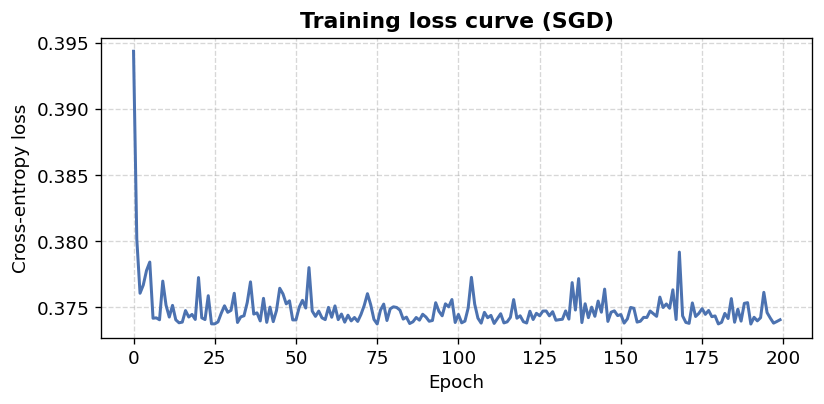

In [7]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 11})

plt.figure(figsize=(7, 3.5))
plt.plot(loss_history, color="#4C72B0", linewidth=1.8)
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training loss curve (SGD)", fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 5 · Prediction and decision boundary (§4.3)

From §4.3:
> *We say yes if P(y=1|x) > 0.5, and no otherwise.*

The decision boundary is at σ(w·x + b) = 0.5, i.e. where z = 0.

In [8]:
def predict_proba(X, w, b):
    """ŷ = σ(Xw + b)  — vectorised form, Eq. 4.13"""
    return sigmoid(X @ w + b)

def predict(X, w, b, threshold=0.5):
    """decision(x) = 1 if P(y=1|x) > 0.5 else 0  (§4.3)"""
    return (predict_proba(X, w, b) >= threshold).astype(int)


y_pred_train = predict(X_train, w, b)
y_pred_test  = predict(X_test,  w, b)
y_prob_test  = predict_proba(X_test, w, b)

print(f"Train predictions: {y_pred_train[:20]}")
print(f"True train labels: {y_train[:20]}")

Train predictions: [0 0 1 1 1 0 0 1 0 1 0 0 1 1 1 1 1 0 1 1]
True train labels: [0 1 1 1 1 0 0 1 0 1 0 0 1 1 1 0 1 0 0 1]


## 6 · Evaluation: accuracy, precision, recall, and confusion matrix

  SLP3 Ch4 Logistic Regression — Test Set
  Accuracy  : 0.8500
  Precision : 0.8535  (macro avg)
  Recall    : 0.8500  (macro avg)
  F1        : 0.8496  (macro avg)

              precision    recall  f1-score   support

    negative       0.89      0.80      0.84        10
    positive       0.82      0.90      0.86        10

    accuracy                           0.85        20
   macro avg       0.85      0.85      0.85        20
weighted avg       0.85      0.85      0.85        20



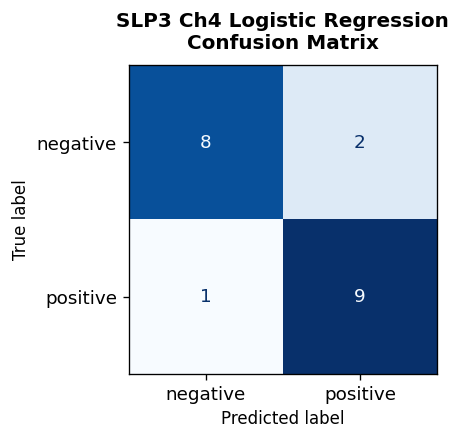

In [9]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

LABEL_NAMES = ["negative", "positive"]

acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, average="macro", zero_division=0)
rec  = recall_score(y_test, y_pred_test, average="macro", zero_division=0)
f1   = f1_score(y_test, y_pred_test, average="macro", zero_division=0)

print("=" * 52)
print("  SLP3 Ch4 Logistic Regression — Test Set")
print("=" * 52)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}  (macro avg)")
print(f"  Recall    : {rec:.4f}  (macro avg)")
print(f"  F1        : {f1:.4f}  (macro avg)")
print()
print(classification_report(y_test, y_pred_test, target_names=LABEL_NAMES, zero_division=0))

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_test, labels=[0, 1])
fig, ax = plt.subplots(figsize=(4.5, 3.8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_NAMES)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("SLP3 Ch4 Logistic Regression\nConfusion Matrix",
             fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Predicted label", fontsize=10)
ax.set_ylabel("True label", fontsize=10)
plt.tight_layout()
plt.show()

## 7 · Predicted vs actual — full test set

In [10]:
# Reconstruct the original (unstandardised) test texts from the split indices
_, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=42, stratify=y_all
)

results_df = pd.DataFrame({
    "text":          df.iloc[test_idx]["text"].values,
    "actual":        [LABEL_NAMES[y] for y in y_test],
    "predicted":     [LABEL_NAMES[y] for y in y_pred_test],
    "P(positive)": y_prob_test.round(4),
    "correct":       y_test == y_pred_test,
})

print(f"Test set: {len(results_df)} documents  |  "
      f"Correct: {results_df['correct'].sum()}  |  "
      f"Wrong: {(~results_df['correct']).sum()}")

# Show all rows, truncating long text
pd.set_option("display.max_colwidth", 80)
results_df[["text", "actual", "predicted", "P(positive)", "correct"]]

Test set: 20 documents  |  Correct: 17  |  Wrong: 3


,text,actual,predicted,P(positive),correct
0,Really appreciate the effort here. The documentation is especially clear.,positive,positive,0.8884,True
1,Really solid work. This should unblock several downstream packages.,positive,positive,0.7666,True
2,Thanks for addressing my earlier comments. The revision is much better.,positive,positive,0.9011,True
3,The performance overhead is negligible according to the benchmarks. Ship it.,positive,negative,0.3671,False
4,The PR is missing a NEWS entry. Not approving without that.,negative,negative,0.0063,True
5,The migration path is unclear and risky. Not ready to approve.,negative,negative,0.0040,True
6,I don't think the CPython core team has signed off on this direction. Blocking.,negative,negative,0.0047,True
7,Happy to approve this. The edge cases are handled correctly.,positive,positive,0.7106,True
8,The ABI tag format proposed here conflicts with existing tooling. Hard no.,negative,negative,0.0002,True
9,The PEP references a superseded design doc. Needs to be updated.,negative,negative,0.3671,True


In [11]:
# ── Misclassified examples ────────────────────────────────────────────────────
misclassified = results_df[~results_df["correct"]]
print(f"Misclassified ({len(misclassified)} documents):")
misclassified[["text", "actual", "predicted", "P(positive)"]]

Misclassified (3 documents):


,text,actual,predicted,P(positive)
3,The performance overhead is negligible according to the benchmarks. Ship it.,positive,negative,0.3671
12,The performance regression here is unacceptable. We need a better solution.,negative,positive,0.6400
17,Strongly opposed. This regresses the behavior we fixed in 3.11.,negative,positive,0.6869


## 8 · Feature weight interpretation

The learned weights tell us exactly what each feature contributes to the
positive-stance decision — directly interpretable as in the book's worked example
(\u00a74.3.1: *\"w\u2081=2.5 is positive, while w\u2082=\u22125.0, meaning negative words are negatively
associated with a positive sentiment decision\"*).

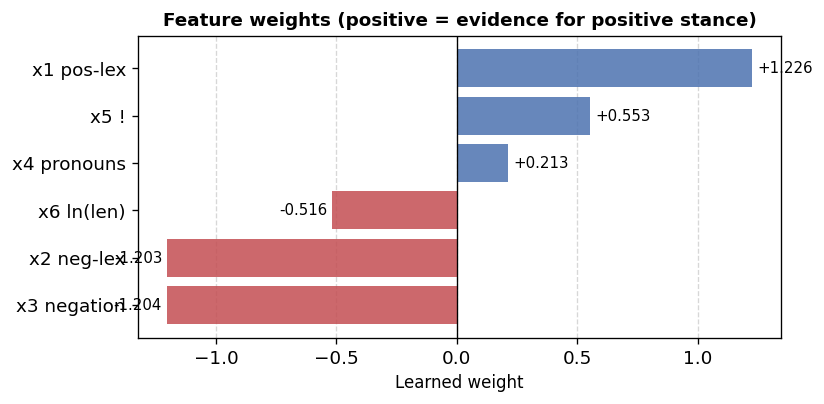


Weight summary:
    feature  weight
x3 negation -1.2036
 x2 neg-lex -1.2031
 x6 ln(len) -0.5164
x4 pronouns  0.2129
       x5 !  0.5534
 x1 pos-lex  1.2260

Bias b = -0.3886


In [12]:
weight_df = pd.DataFrame({
    "feature": feature_names,
    "weight":  w.round(4)
}).sort_values("weight", ascending=True)

colors = ["#C44E52" if v < 0 else "#4C72B0" for v in weight_df["weight"]]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(weight_df["feature"], weight_df["weight"], color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Learned weight", fontsize=10)
ax.set_title("Feature weights (positive = evidence for positive stance)",
             fontsize=11, fontweight="bold")
for bar, val in zip(bars, weight_df["weight"]):
    ax.text(
        val + (0.02 if val >= 0 else -0.02),
        bar.get_y() + bar.get_height() / 2,
        f"{val:+.3f}", va="center",
        ha="left" if val >= 0 else "right", fontsize=9
    )
ax.grid(True, axis="x", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print("\nWeight summary:")
print(weight_df.to_string(index=False))
print(f"\nBias b = {b:+.4f}")